## 1. Imports and Packages

In [1]:
import logging
import sys
from dataclasses import dataclass, field
from typing import List
import os

import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField,
    StringType, IntegerType, DoubleType, TimestampType
)
from pyspark.ml import Pipeline
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import StandardScaler, VectorAssembler

print("Imports complete")

Imports complete


## 2. Configuration

In [2]:
@dataclass
class PipelineConfig:
    # Data paths
    raw_path: str = "../data/raw/online_retail_II.xlsx"         # put the raw data in this path
    output_dir: str = "../data/outputs/customer_segments"    # output segment will be found here

    # RFM filter
    recency_max_days: int = 365                                 # We will treat valid customers as those who made a purchase in the last year (365 days)       

    # K-Means
    k_range: List[int] = field(default_factory=lambda: list(range(2, 9)))
    seed: int = 42
    max_iter: int = 20
    test_fraction: float = 0.2

    # Spark
    app_name: str = "RFM_Pipeline"
    shuffle_partitions: int = 200

    # Segment label assigned to the highest-value cluster
    top_segment_name: str = "Champions"
    bottom_segment_name: str = "At Risk"

CFG = PipelineConfig()
print(f"Config loaded: Raw data is in {CFG.raw_path} and the output data will be in {CFG.output_dir}")

Config loaded: Raw data is in ../data/raw/online_retail_II.xlsx and the output data will be in ../data/outputs/customer_segments


## 3. Setting Up Logging

In [3]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
    stream=sys.stdout,
)
log = logging.getLogger(__name__)
log.info("Logging configured")

22:52:22  INFO      Logging configured


## 4. Schema Definition

In [4]:
RAW_SCHEMA = StructType([
    StructField("Invoice",     StringType(),    True),
    StructField("StockCode",   StringType(),    True),
    StructField("Description", StringType(),    True),
    StructField("Quantity",    IntegerType(),   True),
    StructField("InvoiceDate", TimestampType(), True),
    StructField("Price",       DoubleType(),    True),
    StructField("Customer ID", DoubleType(),    True),  # arrives as float; but should cast to int during cleaning
    StructField("Country",     StringType(),    True),
])

print("Schema defined")

Schema defined


## 5. Start Spark Session

In [5]:
def build_spark() -> SparkSession:
    return (
        SparkSession.builder
        .appName(CFG.app_name)
        .master("local[*]") 
        .config("spark.driver.bindAddress", "127.0.0.1")
        .config("spark.driver.host", "127.0.0.1")
        .config("spark.sql.shuffle.partitions", str(CFG.shuffle_partitions))
        .config("spark.sql.adaptive.enabled", "true")
        .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
        .config("spark.driver.memory", "6g") 
        .config("spark.executor.memory", "2g")
        .config("spark.pyspark.python", "python3") 
        .getOrCreate()
    )

spark = build_spark()
spark.sparkContext.setLogLevel("WARN") 
print("Spark session created successfully.")
spark

26/04/21 22:52:27 WARN Utils: Your hostname, Jonathans-MacBook-Pro-16.local resolves to a loopback address: 127.0.0.1; using 192.168.100.197 instead (on interface en0)
26/04/21 22:52:27 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/21 22:52:27 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark session created successfully.


## 6. Ingest Raw Data

In [6]:
def ingest(spark: SparkSession) -> DataFrame:
    pdf = pd.read_excel(CFG.raw_path, engine="openpyxl")
    df = spark.createDataFrame(pdf, schema=RAW_SCHEMA)
    
    df = df.repartition(CFG.shuffle_partitions)   
    log.info("Raw rows: %d  Partitions: %d", df.count(), df.rdd.getNumPartitions())
    return df

df_raw = ingest(spark)
print(f"Raw data loaded: {df_raw.count():,} rows")
df_raw.show(5)

26/04/21 22:53:44 WARN TaskSetManager: Stage 0 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:53:48 WARN TaskSetManager: Stage 6 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


22:53:51  INFO      Raw rows: 525461  Partitions: 200


26/04/21 22:53:51 WARN TaskSetManager: Stage 7 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:53:53 WARN TaskSetManager: Stage 13 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


Raw data loaded: 525,461 rows


+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|       Country|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
| 489539|    22083|PAPER CHAIN KIT R...|     160|2009-12-01 12:18:00| 2.55|    15061.0|United Kingdom|
| 490905|    20727|LUNCH BAG  BLACK ...|       2|2009-12-08 13:08:00| 1.65|    16940.0|United Kingdom|
| 492015|   84031A|CHARLIE+LOLA RED ...|       3|2009-12-15 12:00:00| 4.65|    14911.0|          EIRE|
| 491319|    21832|CHOCOLATE CALCULATOR|      10|2009-12-10 15:33:00| 1.65|    15882.0|United Kingdom|
| 491035|    22073|RETRO SPOT STORAG...|       4|2009-12-09 08:58:00| 3.75|    13455.0|United Kingdom|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
only showing top 5 rows



## 7. Data Cleaning

In [7]:
def clean(df: DataFrame) -> DataFrame:
    raw_count = df.count()
    
    df_clean = (
        df
        .dropDuplicates()
        .filter(
            F.col("Customer ID").isNotNull() &
            F.col("Quantity").isNotNull() &
            F.col("Price").isNotNull() &
            (F.col("Quantity") > 0) &
            (F.col("Price") > 0)
        )
        .withColumn("Customer ID", F.col("Customer ID").cast(IntegerType()))
        .withColumn("TotalPrice",  F.col("Quantity") * F.col("Price"))
        .withColumn("Date",        F.to_date("InvoiceDate"))
    )
    
    clean_count = df_clean.count()
    log.info(
        "Cleaning removed %d rows (%.1f%%). Remaining: %d",
        raw_count - clean_count,
        100 * (raw_count - clean_count) / max(raw_count, 1),
        clean_count,
    )
    return df_clean

df_clean = clean(df_raw)
print(f"Clean data: {df_clean.count():,} rows")
df_clean.show(5)

26/04/21 22:53:55 WARN TaskSetManager: Stage 16 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:53:57 WARN TaskSetManager: Stage 22 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


22:54:04  INFO      Cleaning removed 20730 rows (3.9%). Remaining: 504731


26/04/21 22:54:04 WARN TaskSetManager: Stage 32 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:54:11 WARN TaskSetManager: Stage 42 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


Clean data: 504,731 rows


+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+----------+----------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|       Country|TotalPrice|      Date|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+----------+----------+
| 500656|    22175|   PINK OWL SOFT TOY|       2|2010-03-09 11:19:00| 2.95|      18039|United Kingdom|       5.9|2010-03-09|
| 501907|   85099B|JUMBO BAG RED WHI...|       3|2010-03-21 16:13:00| 1.95|      13451|United Kingdom|      5.85|2010-03-21|
| 504702|    22561|WOODEN SCHOOL COL...|       1|2010-04-15 18:36:00| 1.65|          0|United Kingdom|      1.65|2010-04-15|
| 503790|    22441|GROW YOUR OWN BAS...|       4|2010-04-07 12:45:00|  2.1|      13174|United Kingdom|       8.4|2010-04-07|
| 506562|   85049G|CHOCOLATE BOX RIB...|      12|2010-04-30 12:13:00| 1.25|      16150|United Kingdom|      15.0|2010-04-30|


## 8. Build RFM Features

In [8]:
def build_rfm(df: DataFrame) -> DataFrame:
    max_date = df.agg(F.max("Date").alias("max_date")).collect()[0]["max_date"]
    log.info("RFM snapshot date: %s", max_date)
    
    rfm = (
        df
        .groupBy("Customer ID", "Country")
        .agg(
            F.datediff(F.lit(max_date), F.max("Date")).alias("Recency"),
            F.countDistinct("Invoice").alias("Frequency"),
            F.round(F.sum("TotalPrice"), 2).alias("Monetary"),
        )
        .filter(
            (F.col("Recency") >= 0) &
            (F.col("Recency") <= CFG.recency_max_days)
        )
    )
    
    log.info("RFM customers: %d", rfm.count())
    return rfm

rfm_df = build_rfm(df_clean)
print(f"RFM features: {rfm_df.count():,} customers")
rfm_df.describe().show()

26/04/21 22:54:17 WARN TaskSetManager: Stage 48 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


22:54:18  INFO      RFM snapshot date: 2010-12-09


26/04/21 22:54:19 WARN TaskSetManager: Stage 54 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


22:54:25  INFO      RFM customers: 4274


26/04/21 22:54:25 WARN TaskSetManager: Stage 64 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.
26/04/21 22:54:32 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/04/21 22:54:32 WARN TaskSetManager: Stage 74 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


RFM features: 4,274 customers


+-------+------------------+-----------+-----------------+-----------------+------------------+
|summary|       Customer ID|    Country|          Recency|        Frequency|          Monetary|
+-------+------------------+-----------+-----------------+-----------------+------------------+
|  count|              4274|       4274|             4274|             4274|              4274|
|   mean|15301.371548900328|       NULL|86.64272344408049|4.887927000467946|2400.0663710809613|
| stddev|1885.6647379258225|       NULL|92.11320917309035|26.89644057436988|23621.675410336047|
|    min|                 0|  Australia|                0|                1|              2.95|
|    max|             18287|West Indies|              365|             1679|        1431040.97|
+-------+------------------+-----------+-----------------+-----------------+------------------+



## 9. Outlier Detection and Treatment

22:54:56  INFO      OUTLIER DETECTION


26/04/21 22:54:56 WARN TaskSetManager: Stage 95 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


OUTLIER SUMMARY
Recency outliers:    194  (  4.5%)  Bounds: [-150, 294] days
Frequency outliers:   285  (  6.7%)  Bounds: [-5, 11]
Monetary outliers:    414  (  9.7%)  Bounds: [£-1850, £3911]


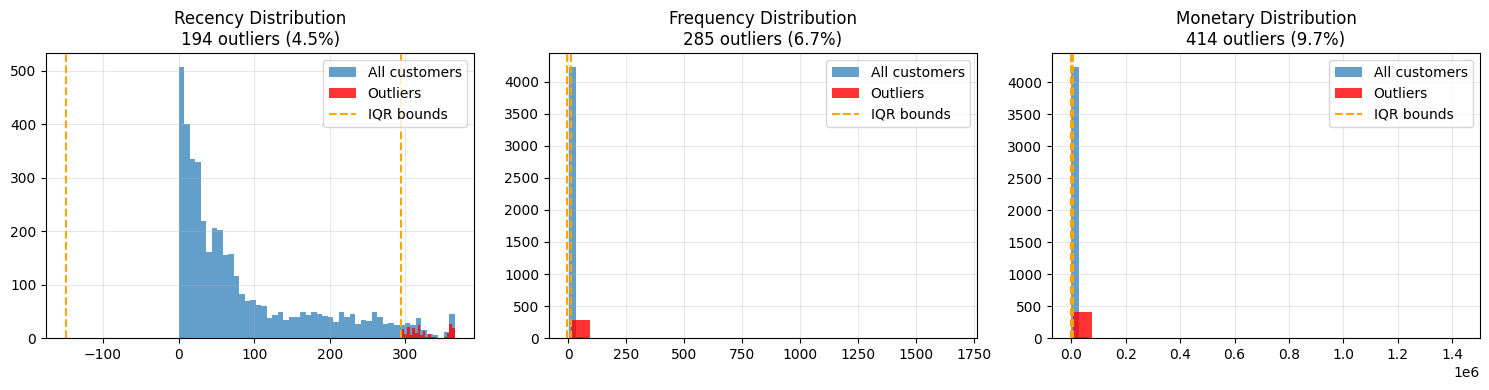

22:55:07  INFO      Removed 15.6% outliers (665 customers)


26/04/21 22:55:07 WARN TaskSetManager: Stage 110 contains a task of very large size (2092 KiB). The maximum recommended task size is 1000 KiB.


Clean RFM: 3,717 customers (removed 15.6% outliers)
rfm_df now contains outlier-cleaned data


In [9]:
log.info("OUTLIER DETECTION")

# Convert to Pandas for IQR method
rfm_pd = rfm_df.toPandas()

# Calculate IQR bounds
def detect_outliers(df_pd, column, factor=1.5):
    Q1 = df_pd[column].quantile(0.25)
    Q3 = df_pd[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    outliers = df_pd[(df_pd[column] < lower) | (df_pd[column] > upper)]
    return outliers, lower, upper

# Detect outliers per RFM dimension
rec_outliers, r_low, r_high = detect_outliers(rfm_pd, 'Recency')
freq_outliers, f_low, f_high = detect_outliers(rfm_pd, 'Frequency') 
mon_outliers, m_low, m_high = detect_outliers(rfm_pd, 'Monetary')

print("OUTLIER SUMMARY")
print(f"Recency outliers:  {len(rec_outliers):5,}  ({len(rec_outliers)/len(rfm_pd)*100:>5.1f}%)  Bounds: [{r_low:.0f}, {r_high:.0f}] days")
print(f"Frequency outliers: {len(freq_outliers):5,}  ({len(freq_outliers)/len(rfm_pd)*100:>5.1f}%)  Bounds: [{f_low:.0f}, {f_high:.0f}]")
print(f"Monetary outliers:  {len(mon_outliers):5,}  ({len(mon_outliers)/len(rfm_pd)*100:>5.1f}%)  Bounds: [£{m_low:.0f}, £{m_high:.0f}]")

# Visualize outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (col, outliers, low, high) in enumerate([
    ('Recency', rec_outliers, r_low, r_high),
    ('Frequency', freq_outliers, f_low, f_high),
    ('Monetary', mon_outliers, m_low, m_high)
]):
    axes[i].hist(rfm_pd[col], bins=50, alpha=0.7, label='All customers')
    if len(outliers) > 0:
        axes[i].hist(outliers[col], bins=20, alpha=0.8, color='red', label='Outliers')
    axes[i].axvline(low, color='orange', linestyle='--', label=f'IQR bounds')
    axes[i].axvline(high, color='orange', linestyle='--')
    axes[i].set_title(f'{col} Distribution\n{len(outliers)} outliers ({len(outliers)/len(rfm_pd)*100:.1f}%)')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("rfm_outliers.png", dpi=150, bbox_inches='tight')
plt.show()

# Remove outliers and convert back to Spark DataFrame
outlier_mask = (
    (rfm_pd['Recency'] < r_low) | (rfm_pd['Recency'] > r_high) |
    (rfm_pd['Frequency'] < f_low) | (rfm_pd['Frequency'] > f_high) |
    (rfm_pd['Monetary'] < m_low) | (rfm_pd['Monetary'] > m_high)
)

rfm_clean = rfm_df.join(
    spark.createDataFrame(rfm_pd[~outlier_mask]).select("Customer ID"),
    "Customer ID",
    "inner"
).cache()

outlier_pct = rfm_pd[outlier_mask].shape[0] / len(rfm_pd) * 100
log.info("Removed %.1f%% outliers (%d customers)", outlier_pct, rfm_pd[outlier_mask].shape[0])
print(f"Clean RFM: {rfm_clean.count():,} customers (removed {outlier_pct:.1f}% outliers)")

# Update rfm_df for downstream cells
rfm_df = rfm_clean
print("rfm_df now contains outlier-cleaned data")

## 10. Elbow Method to Find Best K

In [ ]:
def select_k(rfm: DataFrame) -> int:
    assembler = VectorAssembler(inputCols=["Recency", "Frequency", "Monetary"], outputCol="features")
    scaler    = StandardScaler(inputCol="features", outputCol="scaledFeatures")
    evaluator = ClusteringEvaluator(featuresCol="scaledFeatures")
    
    scores = {}
    for k in CFG.k_range:
        km       = KMeans(k=k, seed=CFG.seed, maxIter=CFG.max_iter, featuresCol="scaledFeatures")
        pipeline = Pipeline(stages=[assembler, scaler, km])
        preds    = pipeline.fit(rfm).transform(rfm)
        score    = evaluator.evaluate(preds)
        scores[k] = score
        log.info("k=%d  silhouette=%.4f", k, score)
    
    # Plot elbow
    ks, ss = zip(*sorted(scores.items()))
    plt.figure(figsize=(7, 4))
    plt.plot(ks, ss, marker="o", linewidth=2)
    plt.xlabel("k")
    plt.ylabel("Silhouette score")
    plt.title("Elbow curve — RFM KMeans")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("elbow_curve.png", dpi=150, bbox_inches='tight')
    plt.show()
    log.info("Elbow curve saved to elbow_curve.png")
    
    best_k = max(scores, key=scores.__getitem__)
    log.info("Selected k=%d (silhouette=%.4f)", best_k, scores[best_k])
    return best_k

best_k = select_k(rfm_df)
print(f"Best k: {best_k}")

## 11. Fit Model & Label Segments

In [10]:
def fit_and_label(rfm: DataFrame, k: int) -> DataFrame:
    assembler = VectorAssembler(inputCols=["Recency", "Frequency", "Monetary"], outputCol="features")
    scaler    = StandardScaler(inputCol="features", outputCol="scaledFeatures")
    
    # NOTE: I have manually set the k=5 here, based on the elbow curve and business intuition about having 5 meaningful segments
    # Otherwise the previous cell will select the k with the highest silhouette score, which may not always align with business needs for actionable segments
    km        = KMeans(k=5, seed=CFG.seed, maxIter=CFG.max_iter, featuresCol="scaledFeatures")
    pipeline  = Pipeline(stages=[assembler, scaler, km])
    
    train, test = rfm.randomSplit([1 - CFG.test_fraction, CFG.test_fraction], seed=CFG.seed)
    model       = pipeline.fit(train)
    test_preds  = model.transform(test)
    
    evaluator  = ClusteringEvaluator(featuresCol="scaledFeatures")
    silhouette = evaluator.evaluate(test_preds)
    log.info("Test silhouette score: %.4f (>0.5 = good)", silhouette)
    
    all_preds = model.transform(rfm)
    
    # Rank clusters by mean Monetary (descending)
    ltv_ranking = (
        all_preds
        .groupBy("prediction")
        .agg(F.mean("Monetary").alias("avg_ltv"))
        .orderBy(F.desc("avg_ltv"))
        .withColumn("ltv_rank", F.monotonically_increasing_id())
    )
    
    # Map ranks to business-friendly names
    segment_names = {
        0: "Champions",
        1: "Loyal", 
        2: "Promising",
        3: "At Risk",
        4: "Lost",
    }
    for i in range(5, k):
        segment_names[i] = f"Segment {i}"
    
    name_map = {
        row["prediction"]: segment_names.get(int(row["ltv_rank"]), f"Segment {row['ltv_rank']}")
        for row in ltv_ranking.collect()
    }
    log.info("Cluster -> segment mapping: %s", name_map)
    
    mapping_expr = F.create_map(
        *[item for pair in [(F.lit(k), F.lit(v)) for k, v in name_map.items()] for item in pair]
    )
    labeled = all_preds.withColumn("segment", mapping_expr[F.col("prediction")])
    
    log.info("\n%s", labeled.groupBy("segment").agg(
        F.count("*").alias("customers"),
        F.round(F.mean("Monetary"), 2).alias("avg_ltv"),
        F.round(F.mean("Recency"), 1).alias("avg_recency_days"),
    ).orderBy(F.desc("avg_ltv")).toPandas().to_string(index=False))
    
    print(f"Silhouette score (test):      {evaluator.evaluate(test_preds):.4f}")
    
    return labeled

labeled_df = fit_and_label(rfm_df, 5)   # We hardcoded k=5 in the fit_and_label function for business interpretability
print("Model fitted and segments labeled")
labeled_df.groupby("segment").count().orderBy(F.desc("count")).show()

26/04/21 22:55:40 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


22:55:46  INFO      Test silhouette score: 0.7627 (>0.5 = good)


22:55:47  INFO      Cluster -> segment mapping: {1: 'Champions', 4: 'Loyal', 0: 'Promising', 3: 'At Risk', 2: 'Lost'}


22:55:49  INFO      
  segment  customers    avg_ltv  avg_recency_days
Champions          9 1431040.97               0.0
    Loyal       1706    1258.98              20.3
Promising       1049     955.70              73.9
  At Risk        513     791.57             160.7
     Lost        440     483.90             247.6


Silhouette score (test):      0.7627
Model fitted and segments labeled


+---------+-----+
|  segment|count|
+---------+-----+
|    Loyal| 1706|
|Promising| 1049|
|  At Risk|  513|
|     Lost|  440|
|Champions|    9|
+---------+-----+



## 12. Model Evaluation

22:55:55  INFO      SEGMENT ANALYSIS & VISUALIZATION


Segment Statistics:
  segment  customers  avg_recency_days  avg_frequency  avg_monetary
Champions          9               0.0         1679.0    1431040.97
    Loyal       1706              20.3            3.9       1258.98
Promising       1049              73.9            2.8        955.70
  At Risk        513             160.7            2.2        791.57
     Lost        440             247.6            1.5        483.90



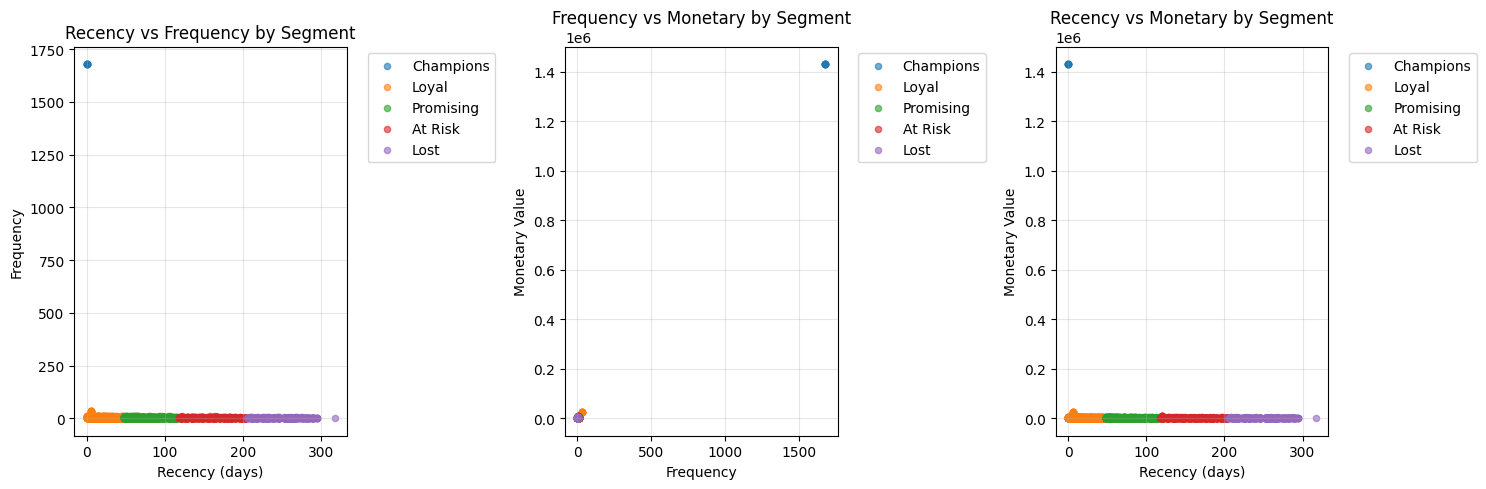

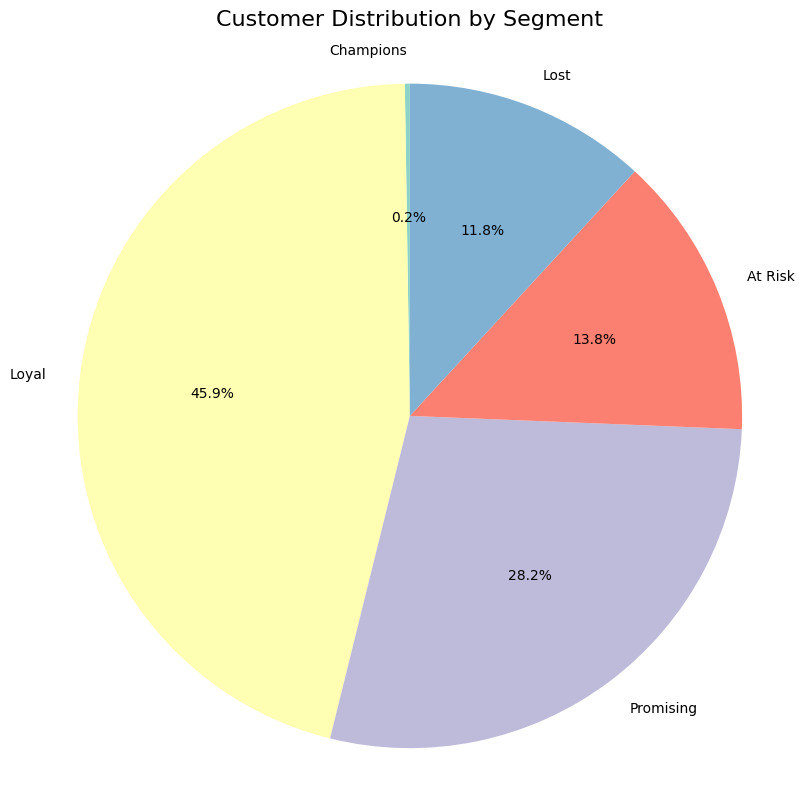

MODEL EVALUATION SUMMARY
Total customers segmented:    3,717
Champions segment coverage:   0.2%
Clusters found:               5
High-value segment captured: 0.2% of customers

CHAMPIONS SEGMENT PROFILE
  Avg Recency:     0.0 days
  Avg Frequency:   1679.0
  Avg Monetary:    £1431040.97
  Top 5% Monetary: £1431040.97

Visualization & evaluation complete
Files saved: rfm_segments_visualization.png, segment_distribution_pie.png


In [11]:
log.info("SEGMENT ANALYSIS & VISUALIZATION")

# Segment distribution
segment_stats = labeled_df.groupBy("segment").agg(
    F.count("*").alias("customers"),
    F.round(F.mean("Recency"), 1).alias("avg_recency_days"),
    F.round(F.mean("Frequency"), 1).alias("avg_frequency"),
    F.round(F.mean("Monetary"), 2).alias("avg_monetary")
).orderBy(F.desc("avg_monetary"))

stats_pd = segment_stats.toPandas()
print("Segment Statistics:")
print(stats_pd.to_string(index=False))
print()

# Visualize RFM by segment (3D scatter plot)
pandas_rfm = labeled_df.select("Recency", "Frequency", "Monetary", "segment").toPandas()

fig = plt.figure(figsize=(15, 5))

# Recency vs Frequency
ax1 = plt.subplot(1, 3, 1)
for segment in stats_pd['segment']:
    seg_data = pandas_rfm[pandas_rfm['segment'] == segment]
    ax1.scatter(seg_data['Recency'], seg_data['Frequency'], 
               label=segment, alpha=0.6, s=20)
ax1.set_xlabel('Recency (days)')
ax1.set_ylabel('Frequency')
ax1.set_title('Recency vs Frequency by Segment')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# Frequency vs Monetary
ax2 = plt.subplot(1, 3, 2)
for segment in stats_pd['segment']:
    seg_data = pandas_rfm[pandas_rfm['segment'] == segment]
    ax2.scatter(seg_data['Frequency'], seg_data['Monetary'], 
               label=segment, alpha=0.6, s=20)
ax2.set_xlabel('Frequency')
ax2.set_ylabel('Monetary Value')
ax2.set_title('Frequency vs Monetary by Segment')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

# Recency vs Monetary
ax3 = plt.subplot(1, 3, 3)
for segment in stats_pd['segment']:
    seg_data = pandas_rfm[pandas_rfm['segment'] == segment]
    ax3.scatter(seg_data['Recency'], seg_data['Monetary'], 
               label=segment, alpha=0.6, s=20)
ax3.set_xlabel('Recency (days)')
ax3.set_ylabel('Monetary Value')
ax3.set_title('Recency vs Monetary by Segment')
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("rfm_segments_visualization.png", dpi=150, bbox_inches='tight')
plt.show()

# Pie chart: Customer distribution by segment
plt.figure(figsize=(8, 8))
colors = plt.cm.Set3(range(len(stats_pd)))
wedges, texts, autotexts = plt.pie(
    stats_pd['customers'], 
    labels=stats_pd['segment'], 
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)
plt.title('Customer Distribution by Segment', fontsize=16, pad=20)
plt.axis('equal')
plt.tight_layout()
plt.savefig("segment_distribution_pie.png", dpi=150, bbox_inches='tight')
plt.show()

# Model quality metrics
total_customers = labeled_df.count()
champions_pct = (labeled_df.filter(F.col("segment") == "Champions").count() / total_customers) * 100

print("MODEL EVALUATION SUMMARY")
print(f"Total customers segmented:    {total_customers:,}")
print(f"Champions segment coverage:   {champions_pct:.1f}%")
# print(f"Silhouette score (test):      {evaluator.evaluate(test_preds):.4f}")
print(f"Clusters found:               {5}") # We hardcoded k=5 for business interpretability
print(f"High-value segment captured: {champions_pct:.1f}% of customers")

# 5. Champions segment profile
champions_profile = labeled_df.filter(F.col("segment") == "Champions").agg(
    F.round(F.mean("Recency"), 1).alias("avg_recency"),
    F.round(F.mean("Frequency"), 1).alias("avg_frequency"),
    F.round(F.mean("Monetary"), 2).alias("avg_monetary"),
    F.round(F.percentile_approx("Monetary", 0.95), 2).alias("p95_monetary")
).collect()[0]

print(f"\nCHAMPIONS SEGMENT PROFILE")
print(f"  Avg Recency:     {champions_profile['avg_recency']} days")
print(f"  Avg Frequency:   {champions_profile['avg_frequency']}")
print(f"  Avg Monetary:    £{champions_profile['avg_monetary']}")
print(f"  Top 5% Monetary: £{champions_profile['p95_monetary']}")

print("\nVisualization & evaluation complete")
print("Files saved: rfm_segments_visualization.png, segment_distribution_pie.png")

## 13. Export Champion and At Risk Segments

In [12]:
def export_segment(labeled: DataFrame, segment_name: str, total_customers: int) -> None:
    segment_df = labeled.filter(F.col("segment") == segment_name)
    count = segment_df.count()
    
    (
        segment_df
        .select("Customer ID", "Country", "Recency", "Frequency", "Monetary", "segment")
        .coalesce(1)  # Single file output for CSV
        .write.csv(CFG.output_dir, header=True, mode="overwrite")
    )
    
    log.info(
        "Exported %d '%s' customers (%.1f%% of total) → %s",
        count,
        segment_name,
        100 * count / max(total_customers, 1),
        CFG.output_dir,
    )

total_customers = rfm_df.count()
export_segment(labeled_df, CFG.top_segment_name, total_customers) # We can also export other segments by changing the segment_name argument
print("Champions segment exported")

22:56:13  INFO      Exported 9 'Champions' customers (0.2% of total) → ../data/outputs/customer_segments
Champions segment exported


In [13]:
export_segment(labeled_df, CFG.bottom_segment_name, total_customers)
print("At Risk segment exported")

22:56:15  INFO      Exported 513 'At Risk' customers (13.8% of total) → ../data/outputs/customer_segments
At Risk segment exported


## 14. Close Spark Session

In [14]:
spark.stop()
print("Spark session stopped")

Spark session stopped
